In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models.segmentation as models
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define Hyperparameters and Model Configuration
num_epochs = 30
batch_size = 16
patience = 3
num_classes = 2 # Background + Object
image_size = 256
weight_decay = 1e-5


from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive')
# !unzip dataset.zip

base_dir = '/content/drive/MyDrive/VOC2012_train_val/VOC2012_train_val'
image_dir = os.path.join(base_dir, 'JPEGImages')
mask_dir = os.path.join(base_dir, 'SegmentationClass')

all_mask_names = sorted(os.listdir(mask_dir))
images_with_any_object = []
object_class_ids = set(range(1, 21))

for mask_name in all_mask_names:
    image_name = mask_name.replace('.png', '.jpg')
    image_path = os.path.join(image_dir, image_name)
    mask_path = os.path.join(mask_dir, mask_name)

    if os.path.exists(image_path):
        try:
            mask = Image.open(mask_path)
            mask_np = np.array(mask)

            if object_class_ids.intersection(set(np.unique(mask_np))):
                images_with_any_object.append(image_name)
        except Exception:
            continue

print(f"Found {len(images_with_any_object)} images with objects.")

Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/VOC2012_train_val/VOC2012_train_val/SegmentationClass'

In [ ]:
# Define transforms
target_size = (256, 256)
resize_transform = T.Resize(target_size, interpolation=Image.NEAREST)
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

class VOCSegmentationDataset(Dataset):
    def __init__(self, filenames, image_dir, mask_dir, resize_transform, normalize_transform, object_class_ids):
        self.filenames = filenames
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.resize_transform = resize_transform
        self.normalize_transform = normalize_transform
        self.object_class_ids = object_class_ids

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        image_name = self.filenames[idx]
        image_path = os.path.join(self.image_dir, image_name)
        mask_name = image_name.replace('.jpg', '.png')
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        image = self.resize_transform(image)
        mask = self.resize_transform(mask)

        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        rotation_degrees = random.randint(-10, 10)
        image = TF.rotate(image, rotation_degrees)
        mask = TF.rotate(mask, rotation_degrees)

        mask_np = np.array(mask)
        binary_mask = np.zeros_like(mask_np, dtype=np.float32)
        for obj_id in self.object_class_ids:
            binary_mask[mask_np == obj_id] = 1

        image = T.ToTensor()(image)
        image = self.normalize_transform(image)
        binary_mask = torch.from_numpy(binary_mask).unsqueeze(0)

        return image, binary_mask

random.seed(42)
random.shuffle(images_with_any_object)
train_split = int(len(images_with_any_object) * 0.8)
val_split = int(len(images_with_any_object) * 0.1)

train_filenames = images_with_any_object[:train_split]
val_filenames = images_with_any_object[train_split:train_split + val_split]
test_filenames = images_with_any_object[train_split + val_split:]


train_dataset = VOCSegmentationDataset(train_filenames, image_dir, mask_dir, resize_transform, normalize, object_class_ids)
val_dataset = VOCSegmentationDataset(val_filenames, image_dir, mask_dir, resize_transform, normalize, object_class_ids)
test_dataset = VOCSegmentationDataset(test_filenames, image_dir, mask_dir, resize_transform, normalize, object_class_ids)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [ ]:
def iou_score(outputs, masks):
    predicted_masks = torch.sigmoid(outputs)
    predicted_masks = (predicted_masks > 0.5).float()
    outputs_flat = predicted_masks.view(-1)
    masks_flat = masks.view(-1)
    intersection = (outputs_flat * masks_flat).sum()
    union = outputs_flat.sum() + masks_flat.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()

def dice_score(outputs, masks):
    predicted_masks = torch.sigmoid(outputs)
    predicted_masks = (predicted_masks > 0.5).float()
    outputs_flat = predicted_masks.view(-1)
    masks_flat = masks.view(-1)
    intersection = (outputs_flat * masks_flat).sum()
    dice = (2. * intersection + 1e-6) / (outputs_flat.sum() + masks_flat.sum() + 1e-6)
    return dice.item()

def pixel_accuracy(outputs, masks):
    predicted_masks = torch.sigmoid(outputs)
    predicted_masks = (predicted_masks > 0.5).float()
    correct_pixels = (predicted_masks == masks).float().sum()
    total_pixels = torch.numel(masks)
    accuracy = correct_pixels / total_pixels
    return accuracy.item()

def visualize_predictions(model, dataloader, num_samples=5):
    model.eval()
    samples = 0

    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)["out"]

            preds = (torch.sigmoid(outputs) > 0.5).float().squeeze(1).cpu().numpy()

            for i in range(imgs.size(0)):
                # Undo normalization to get the original image colors
                un_normalize = T.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
                original_image = un_normalize(imgs[i]).cpu().permute(1, 2, 0).numpy()
                original_image = np.clip(original_image, 0, 1)

                mask_gt = masks[i].cpu().squeeze(0).numpy()
                mask_pred = preds[i]

                # Create a new image with a black background and the object in its original color
                masked_image_pred = np.zeros_like(original_image)
                masked_image_pred[mask_pred.astype(bool)] = original_image[mask_pred.astype(bool)]

                # Create the same visualization for the ground truth
                masked_image_gt = np.zeros_like(original_image)
                masked_image_gt[mask_gt.astype(bool)] = original_image[mask_gt.astype(bool)]

                fig, axs = plt.subplots(1, 3, figsize=(12,4))
                axs[0].imshow(original_image); axs[0].set_title("Original Image"); axs[0].axis("off")
                axs[1].imshow(masked_image_gt); axs[1].set_title("Ground Truth Masked"); axs[1].axis("off")
                axs[2].imshow(masked_image_pred); axs[2].set_title("Prediction Masked"); axs[2].axis("off")
                plt.show()

                samples += 1
                if samples >= num_samples:
                    return

def evaluate_model(model, dataloader):
    model.eval()
    metrics = {"IoU": [], "Dice": [], "PixelAcc": []}
    with torch.no_grad():
        for imgs, masks in tqdm(dataloader, desc="Evaluating"):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)["out"]
            metrics["IoU"].append(iou_score(outputs, masks))
            metrics["Dice"].append(dice_score(outputs, masks))
            metrics["PixelAcc"].append(pixel_accuracy(outputs, masks))
    print(f"Mean IoU: {np.mean(metrics['IoU']):.4f}, Mean Dice: {np.mean(metrics['Dice']):.4f}, Pixel Accuracy: {np.mean(metrics['PixelAcc']):.4f}")

In [ ]:
def train_model(model, train_loader, val_loader, lr, num_epochs=num_epochs, patience=patience):
    best_val_loss = float("inf")
    patience_counter = 0
    backbone_frozen = True
    best_model_wts = None

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    weight_tensor = torch.tensor([1.5], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=weight_tensor)

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss = 0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Training]", leave=False):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)["out"]
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} [Validation]", leave=False):
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)["out"]
                loss = criterion(outputs, masks)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch}/{num_epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = model.state_dict()
            torch.save(best_model_wts, f"deeplabv3_best_lr_{lr}.pth")
            print("Best model updated!")
            patience_counter = 0
        else:
            patience_counter += 1

        if backbone_frozen and epoch >= 2:
            for param in model.backbone.parameters():
                param.requires_grad = True
            print("Backbone unfrozen, fine-tuning full model!")
            backbone_frozen = False

        scheduler.step()
        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

    if best_model_wts:
        model.load_state_dict(best_model_wts)
    return model


--- Starting Final Training with Best Learning Rate: 5e-05 ---


Epoch 1/30 - Train Loss: 0.3851, Val Loss: 0.3030, LR: 0.000050
Best model updated!


Epoch 2/30 - Train Loss: 0.2618, Val Loss: 0.2781, LR: 0.000050
Best model updated!
Backbone unfrozen, fine-tuning full model!


Epoch 3/30 - Train Loss: 0.2151, Val Loss: 0.2705, LR: 0.000050
Best model updated!


Epoch 4/30 - Train Loss: 0.1875, Val Loss: 0.2568, LR: 0.000050
Best model updated!


...

Epoch 9/30 - Train Loss: 0.1267, Val Loss: 0.2391, LR: 0.000025


Epoch 10/30 - Train Loss: 0.1216, Val Loss: 0.2448, LR: 0.000025


Epoch 11/30 - Train Loss: 0.1161, Val Loss: 0.2404, LR: 0.000013
Early stopping triggered!

--- Final Training Complete ---


Evaluating: 100%|██████████| 19/19 [00:10<00:00,  1.83it/s]


Mean IoU: 0.7548, Mean Dice: 0.8575, Pixel Accuracy: 0.9266


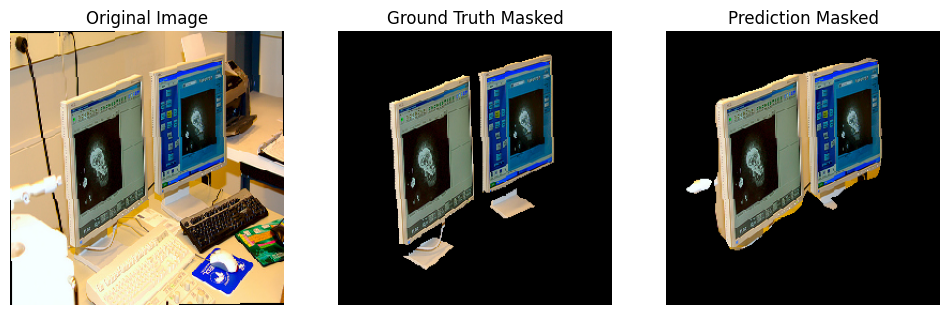

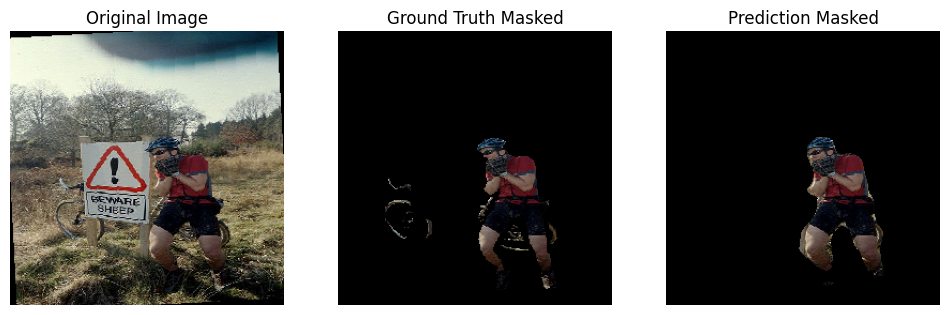

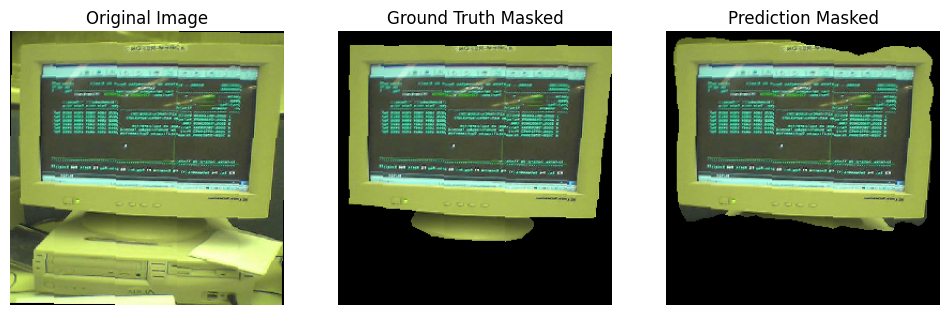

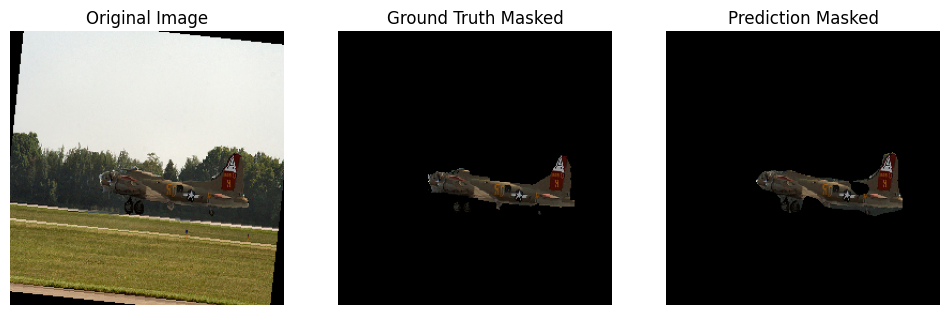

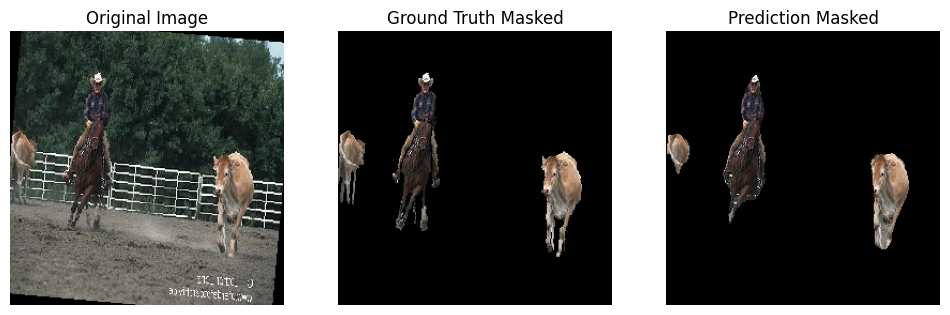

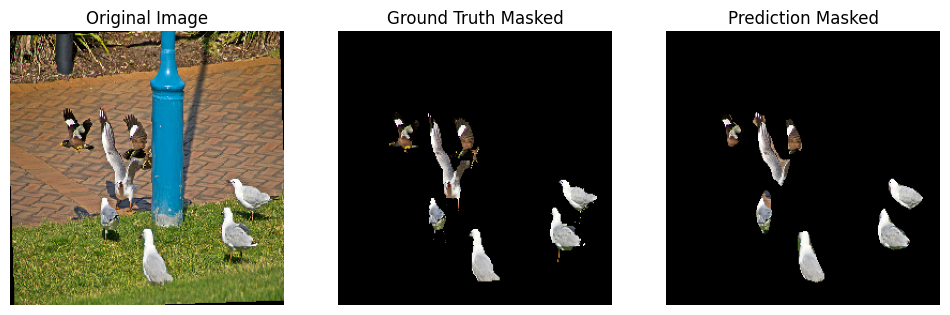

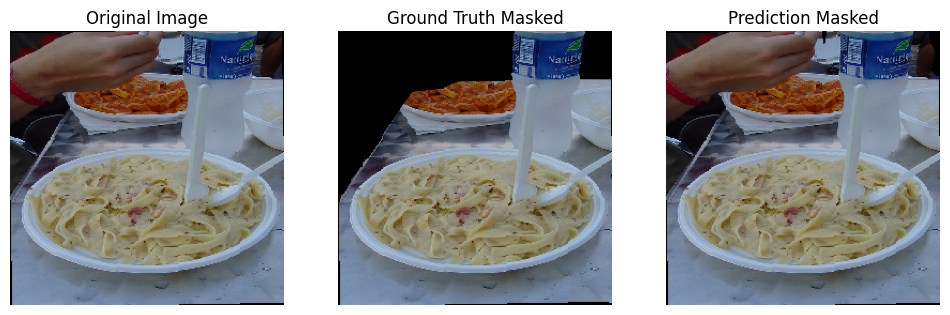

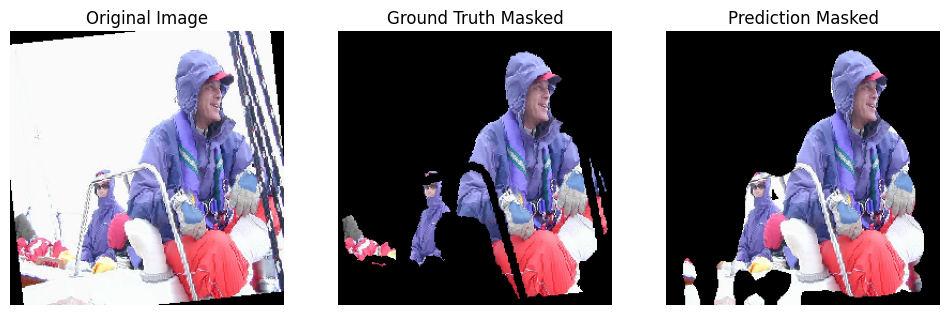

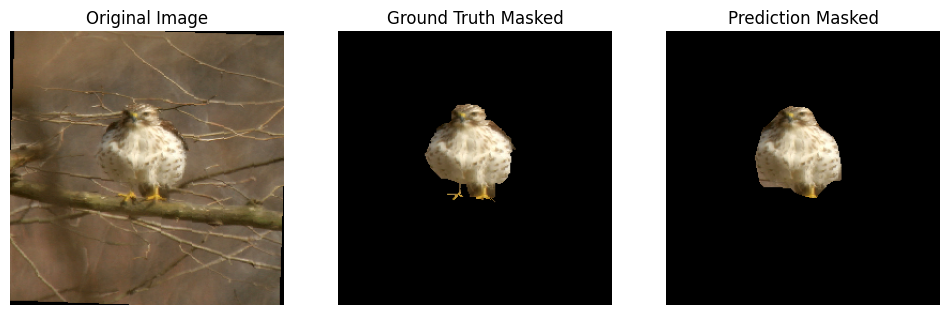

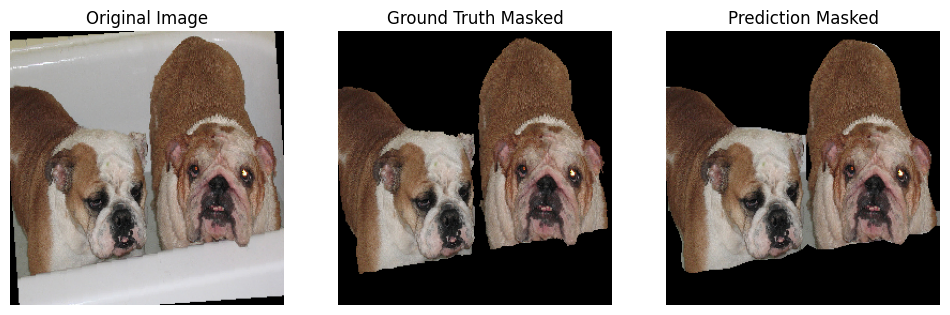

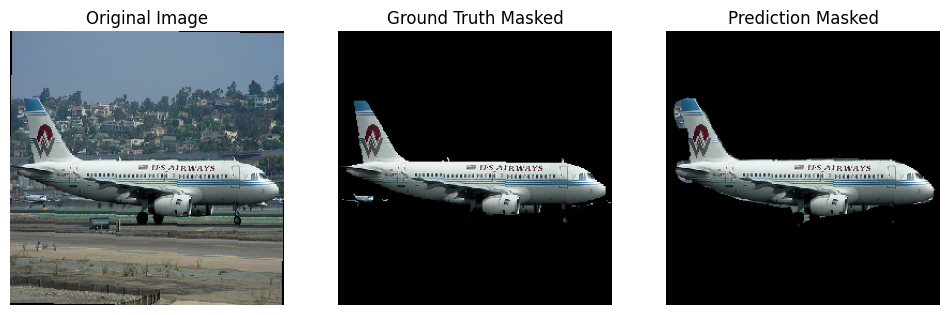

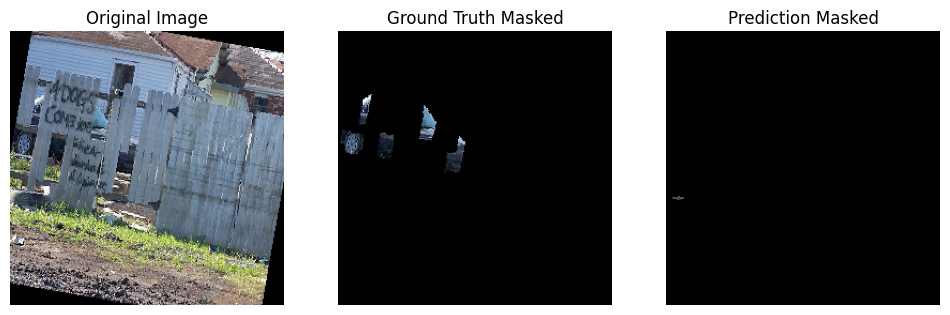

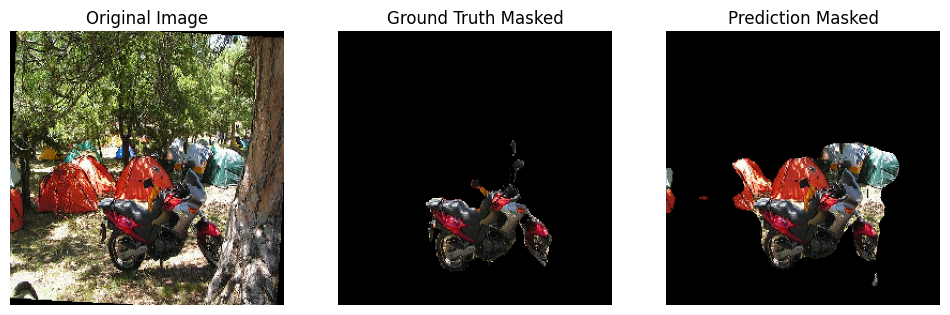

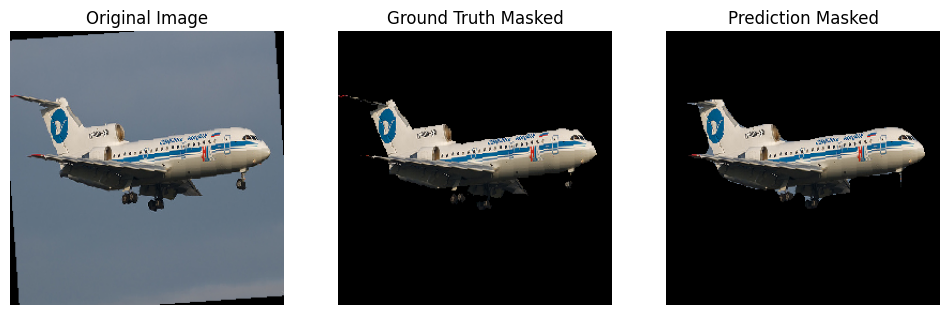

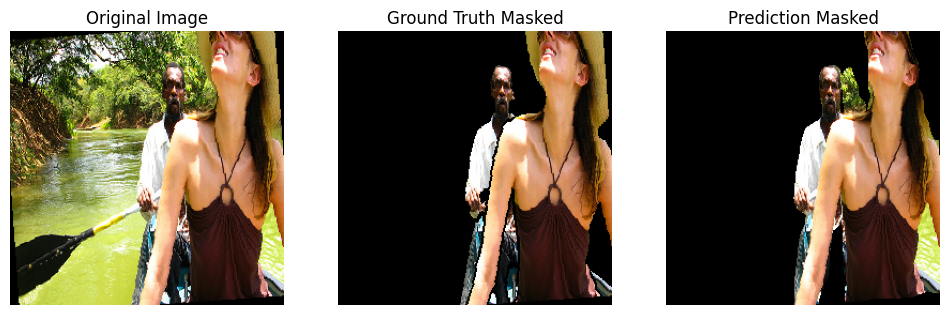

In [ ]:
# =========================================================================
# Main Execution - Single Best Learning Rate
# =========================================================================

best_lr = 5e-5

print(f"\n--- Starting Final Training with Best Learning Rate: {best_lr} ---")

model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)
model.to(device)

trained_model = train_model(model, train_loader, val_loader, lr=best_lr)

print("\n--- Final Training Complete ---")

evaluate_model(trained_model, val_loader)

visualize_predictions(trained_model, val_loader, num_samples=15)

In [ ]:
from google.colab import files

# This will download the best-performing model from your Drive
files.download('deeplabv3_best_lr_5e-05.pth')

In [ ]:
import os

# Define the file path you want to check
# If you downloaded it to the current directory, use the filename
file_path = 'deeplabv3_best_lr_5e-05.pth'

if os.path.exists(file_path):
    print(f"✅ The file '{file_path}' exists.")
else:
    print(f"❌ The file '{file_path}' was not found.")

# Or, if you want to check the full path in Google Drive
drive_file_path = '/content/drive/MyDrive/deeplabv3_best_lr_5e-05.pth'
if os.path.exists(drive_file_path):
    print(f"✅ The file '{drive_file_path}' exists.")
else:
    print(f"❌ The file '{drive_file_path}' was not found.")

✅ The file 'deeplabv3_best_lr_5e-05.pth' exists.
✅ The file '/content/drive/MyDrive/deeplabv3_best_lr_5e-05.pth' exists.


Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


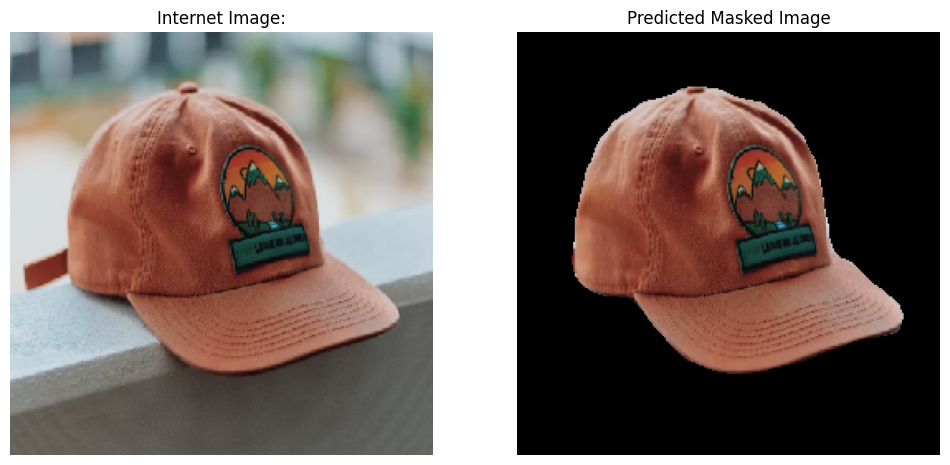

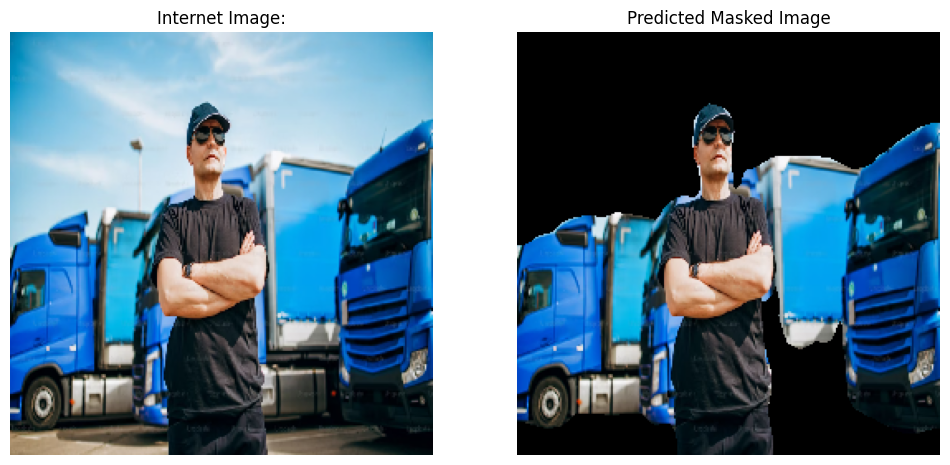

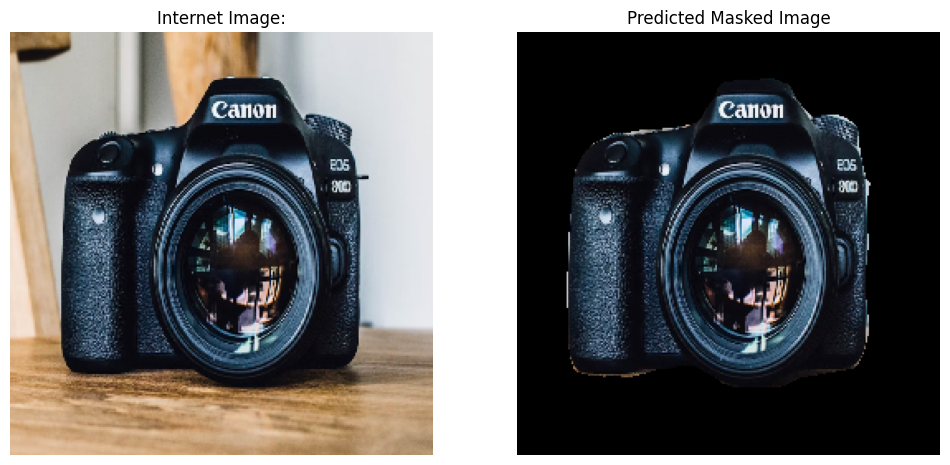

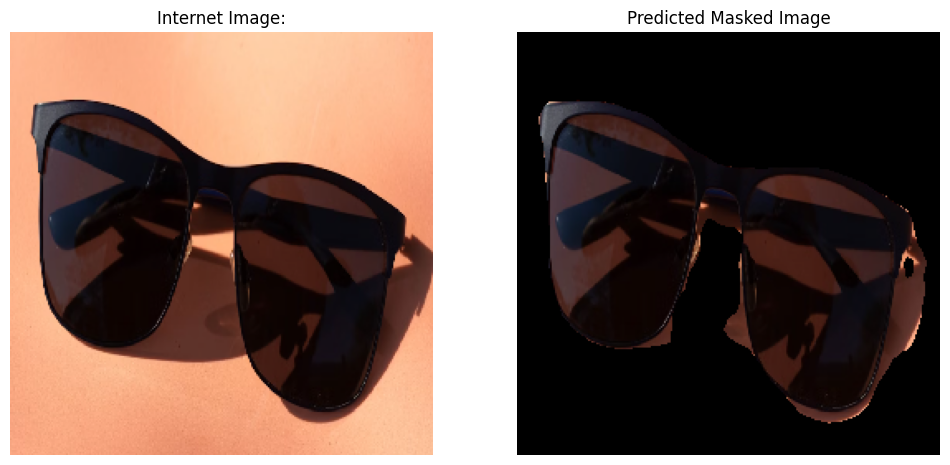

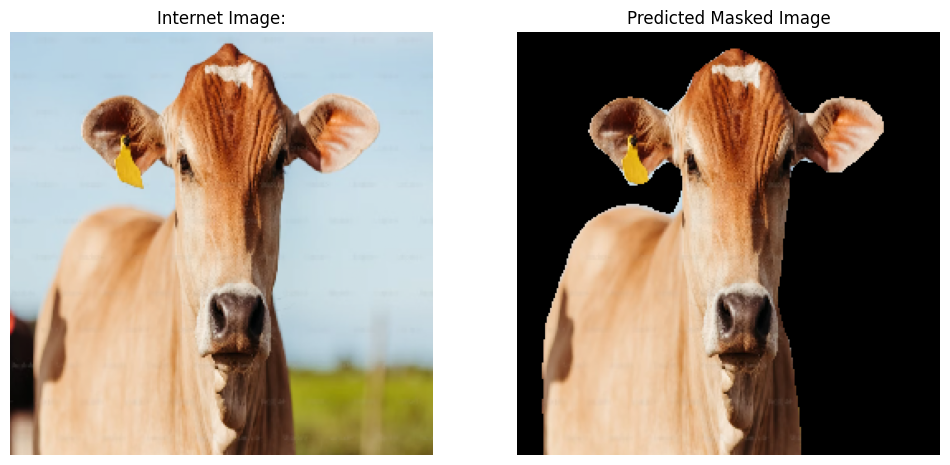

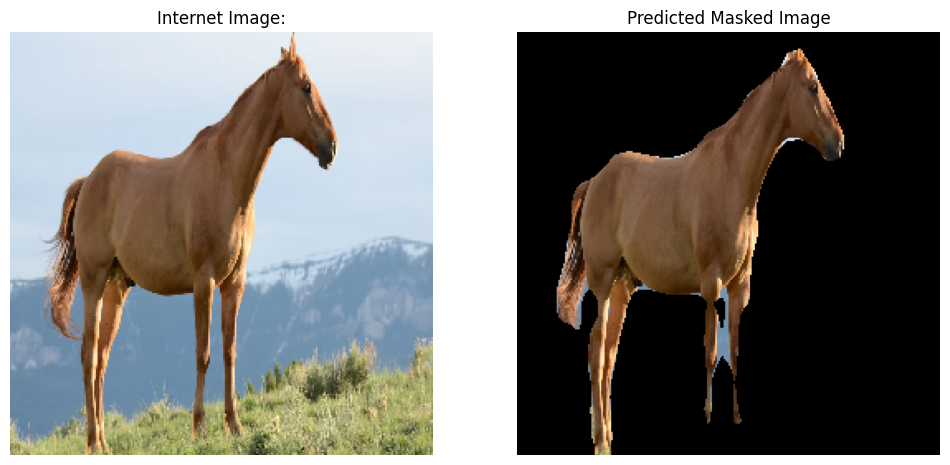

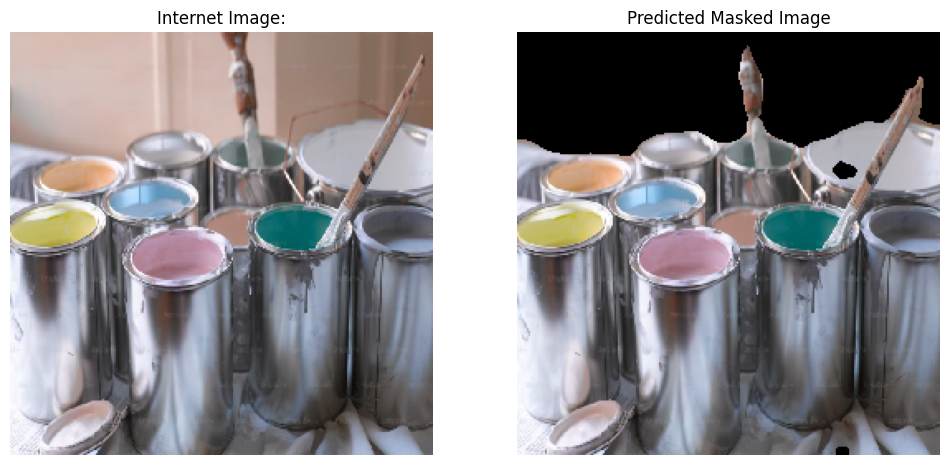

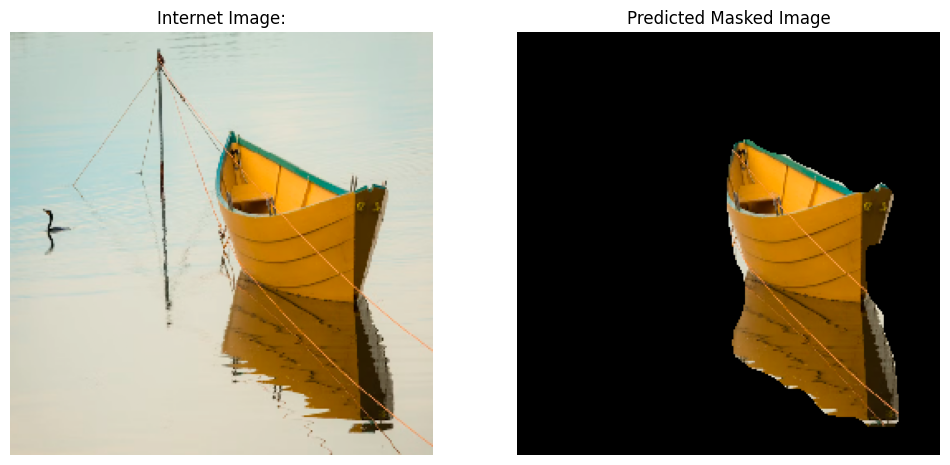

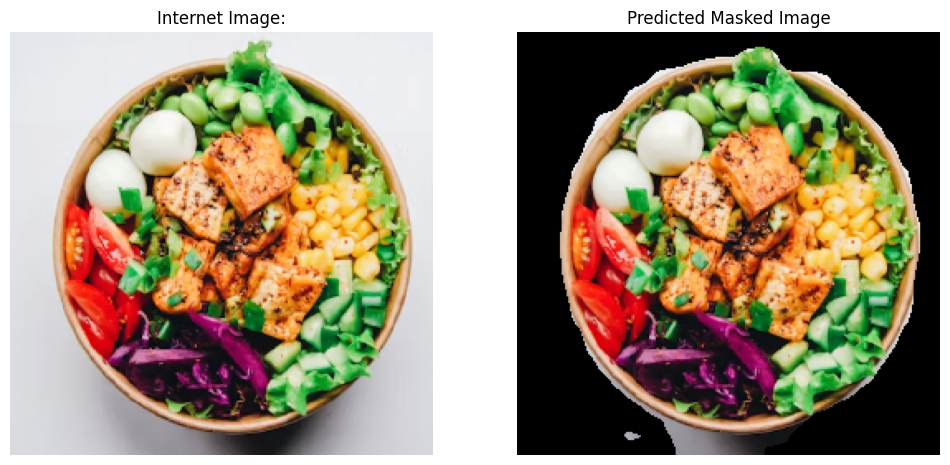

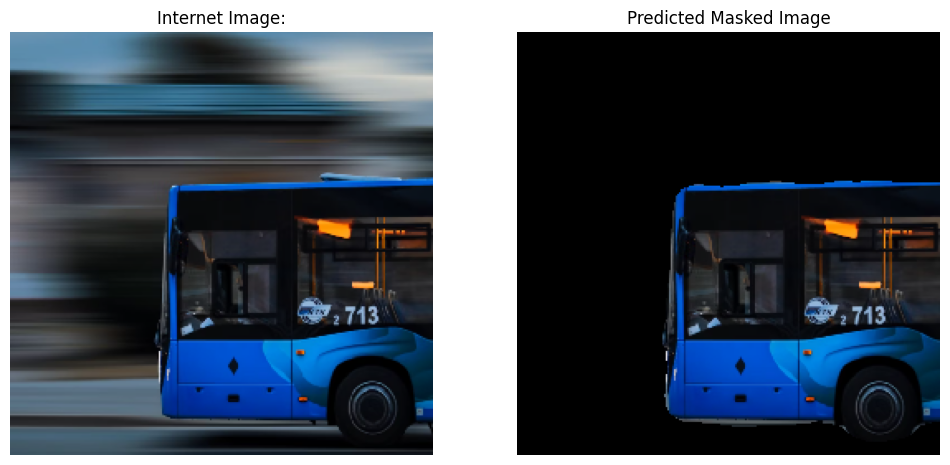

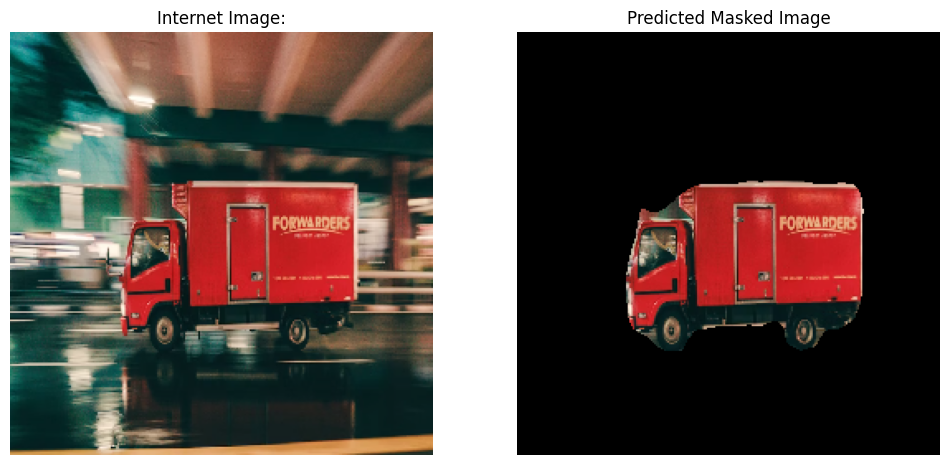

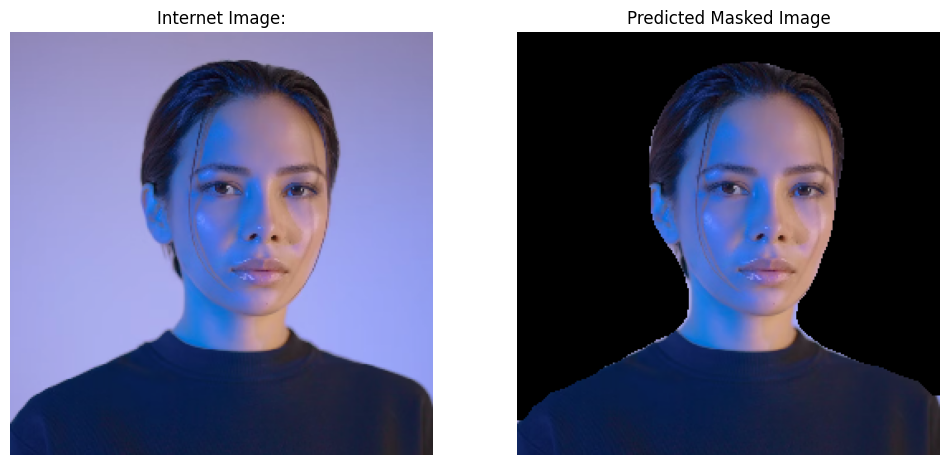

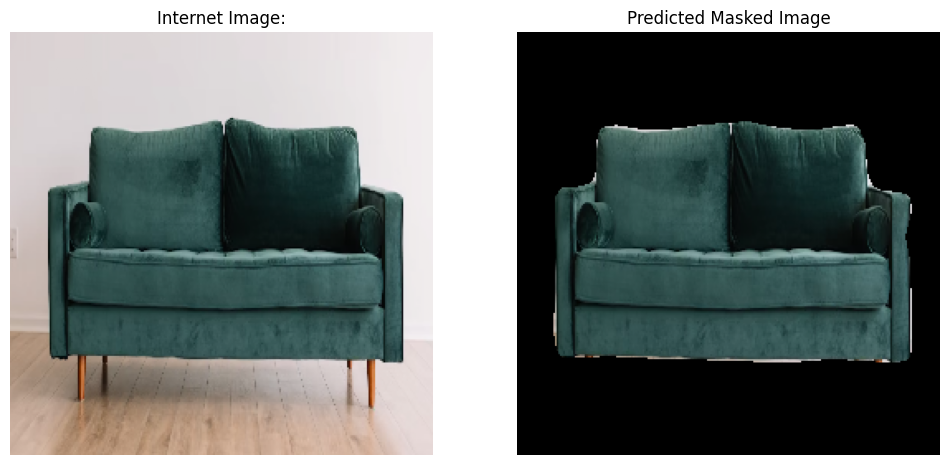

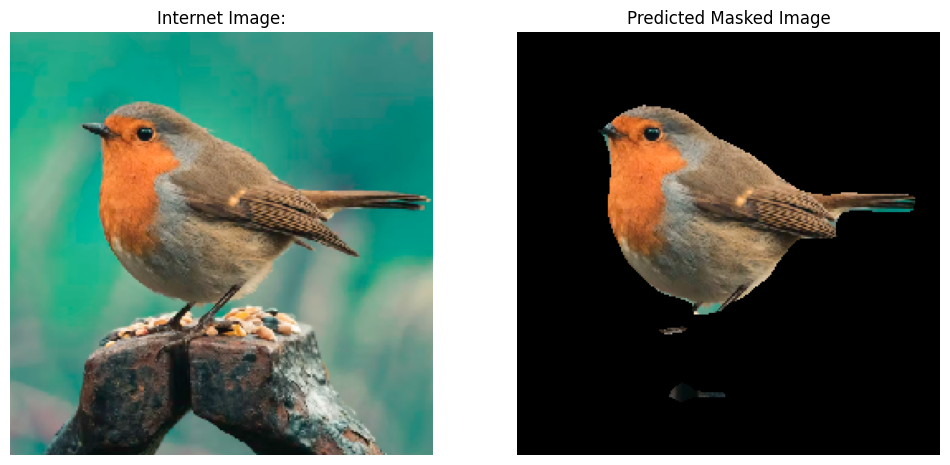

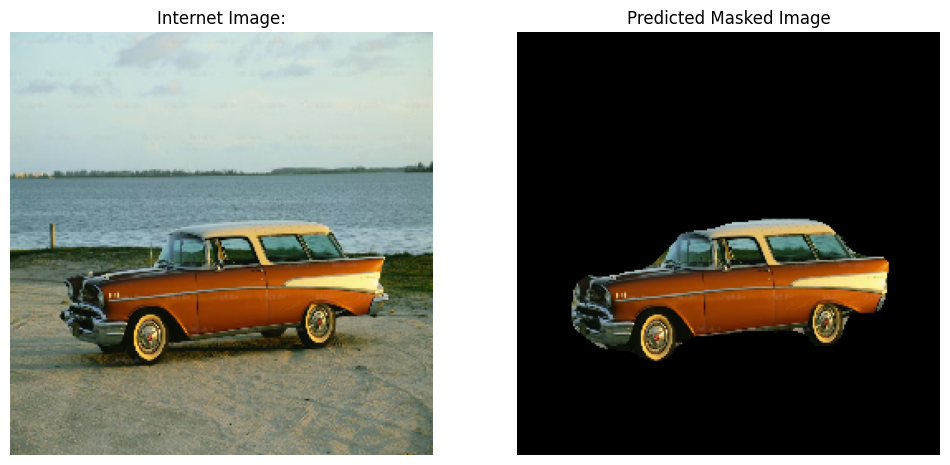

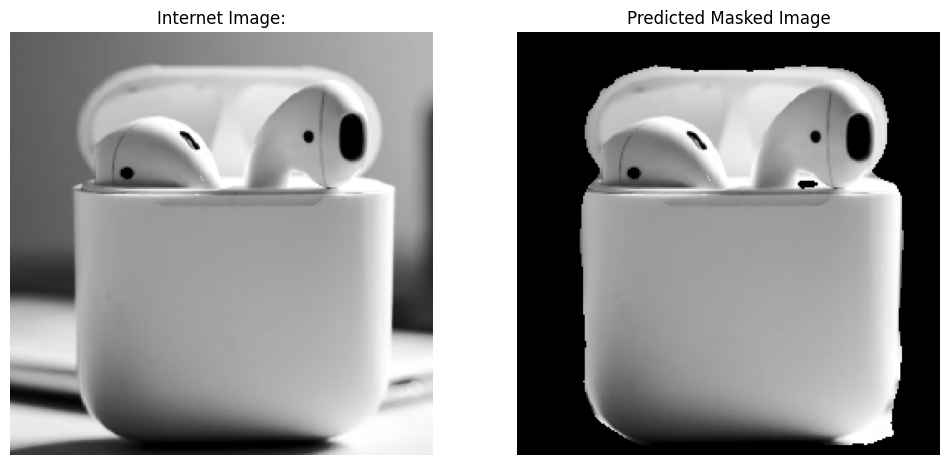

In [20]:
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
import torchvision.transforms as T
import torchvision.models.segmentation as models
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import matplotlib.pyplot as plt
import os
import random

# --- 1. Setup ---
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Mount Google Drive to access your files
from google.colab import drive
drive.mount('/content/drive')

# --- 2. Load the model architecture and weights ---
# Instantiate the DeepLabV3 architecture (must be the same as in training)
model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)

# Set the path to your saved model file in Google Drive
model_path = '/content/drive/MyDrive/deeplabv3_best_lr_5e-05.pth' # <-- Check this path is correct
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)

# Set the model to evaluation mode
model.eval()

# --- 3. Load and preprocess the new images ---
# Set the path to the folder containing your images
image_folder_path = '/content/drive/MyDrive/random_images' # <-- This is your folder's path
image_files = [f for f in os.listdir(image_folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

if not image_files:
    print("No images found in the specified folder.")
else:
    # Preprocessing transforms (must match your training transforms)
    resize_transform = T.Resize((256, 256), interpolation=Image.NEAREST)
    normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    # --- 4. Make predictions and visualize ---
    num_samples = len(image_files) # Set to the number of images you have (16)

    for image_name in image_files:
        image_path = os.path.join(image_folder_path, image_name)
        image_pil = Image.open(image_path).convert("RGB")

        # Apply transforms
        image_tensor = T.ToTensor()(resize_transform(image_pil))
        image_tensor = normalize(image_tensor).unsqueeze(0) # Add a batch dimension

        # Make a prediction
        with torch.no_grad():
            outputs = model(image_tensor.to(device))['out']
            predicted_mask = (torch.sigmoid(outputs) > 0.5).float().squeeze(0).cpu().numpy().squeeze()

        # Undo normalization to get the original image colors for visualization
        un_normalize = T.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
        original_image = un_normalize(image_tensor.squeeze(0)).cpu().permute(1, 2, 0).numpy()
        original_image = np.clip(original_image, 0, 1)

        # Create a new image with a black background and the object in its original color
        masked_image_pred = np.zeros_like(original_image)
        masked_image_pred[predicted_mask.astype(bool)] = original_image[predicted_mask.astype(bool)]

        # Visualize the prediction
        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
        axs[0].imshow(original_image); axs[0].set_title(f'Internet Image:'); axs[0].axis('off')
        axs[1].imshow(masked_image_pred); axs[1].set_title('Predicted Masked Image'); axs[1].axis('off')
        plt.show()